# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.2

NGSOLVE = True

lc = 2.

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions, U
# mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=lc, lc=lc)
# mesh = CleanCircle(R=R, verbosity=0, lc=lc)
R = 0.1
mesh = U(R=R, verbosity=0, Lc=lc, lc=lc)


In [2]:
mesh.n_triangles

485

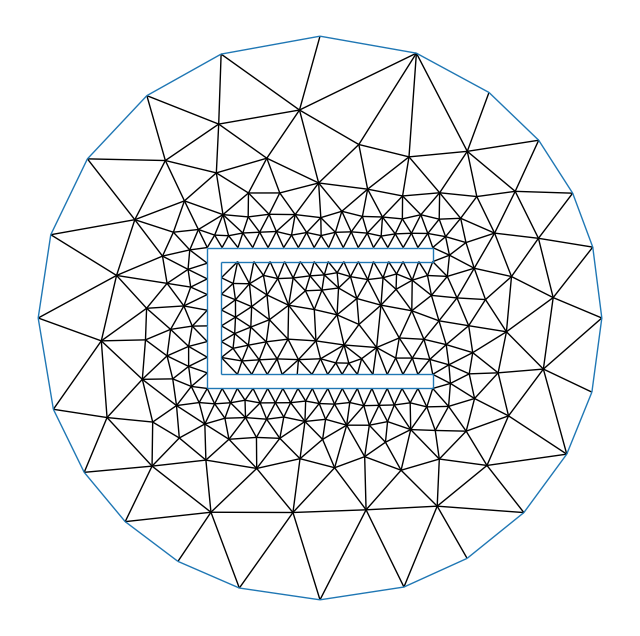

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
#mesh.curve_region(Regions.d_Omega, radius=r)


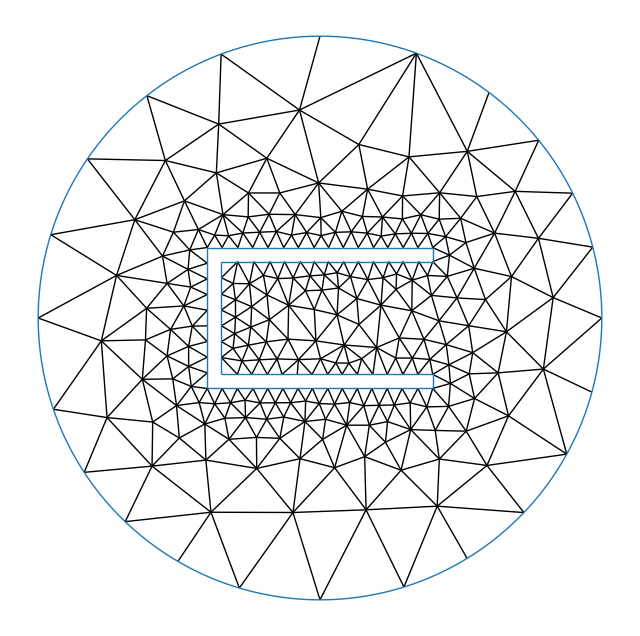

In [ ]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [12]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 20
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [51]:
from trefftz.dg.basis import LinearlySpacedBasis
from scipy.constants import c
f = 8E9
k = 2*np.pi*f/c
print(k)
Ntheta = 5
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

167.66760175613453


and an assembler:

In [52]:
basis.N_DOF

2425

In [53]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [54]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [55]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [56]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 23/23 [00:00<00:00, 70.00edge/s]


region: d_Omega


Interior: 100%|██████████| 678/678 [00:00<00:00, 2053.31edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 23/23 [04:13<00:00, 11.03s/edge]


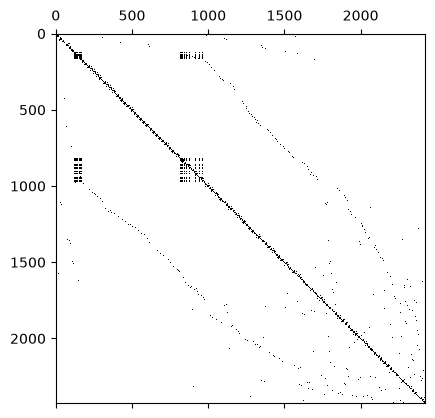

In [57]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [58]:
b = P.assemble_RHS()

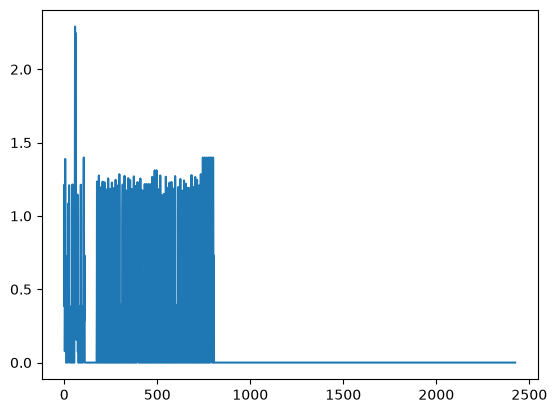

In [59]:
import numpy as np 
plt.plot(np.abs(b))

In [60]:
P.solve()

In [61]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 0.19889382+0.08007884j, -0.08544029-0.03113211j,
        -0.333218  -0.10291246j,  0.27850111-0.84118639j,
         0.19718436+0.29550447j],
       [-0.03385451+0.14351135j, -0.0107407 -0.14569894j,
        -0.33146729-0.22966978j,  0.43856813-0.50658087j,
        -0.18791325+0.07462074j],
       [ 0.14677945+0.08317918j, -0.10868423-0.09513896j,
        -0.26231202-0.222625j  ,  0.19882324-0.73840706j,
         0.07786302+0.18596162j],
       ...,
       [-0.52789852+0.85068874j, -0.09961887+0.25071382j,
        -0.05598968+0.05116756j, -0.01171441-0.09619352j,
        -0.15783613+0.24120029j],
       [-0.68458273+0.81517983j, -0.0530633 +0.36316581j,
        -0.12252985+0.03047945j, -0.01509812+0.04275431j,
         0.02004386+0.34130404j],
       [-0.48338603+0.50268678j,  0.02481603+0.56116553j,
        -0.21389924-0.00375721j, -0.17497857+0.16180439j,
        -0.23918484+0.43071505j]], shape=(485, 5))

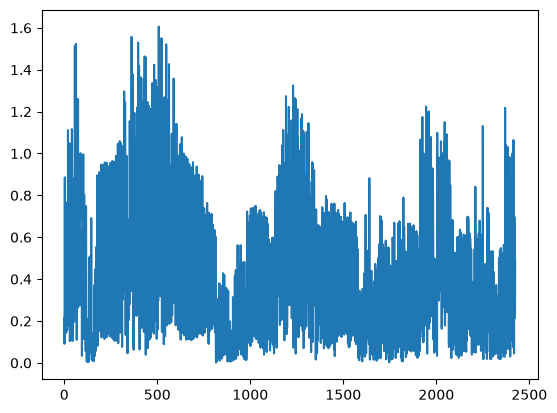

In [62]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [63]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [64]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-0.1), np.float64(0.1), np.float64(-0.1), np.float64(0.1))

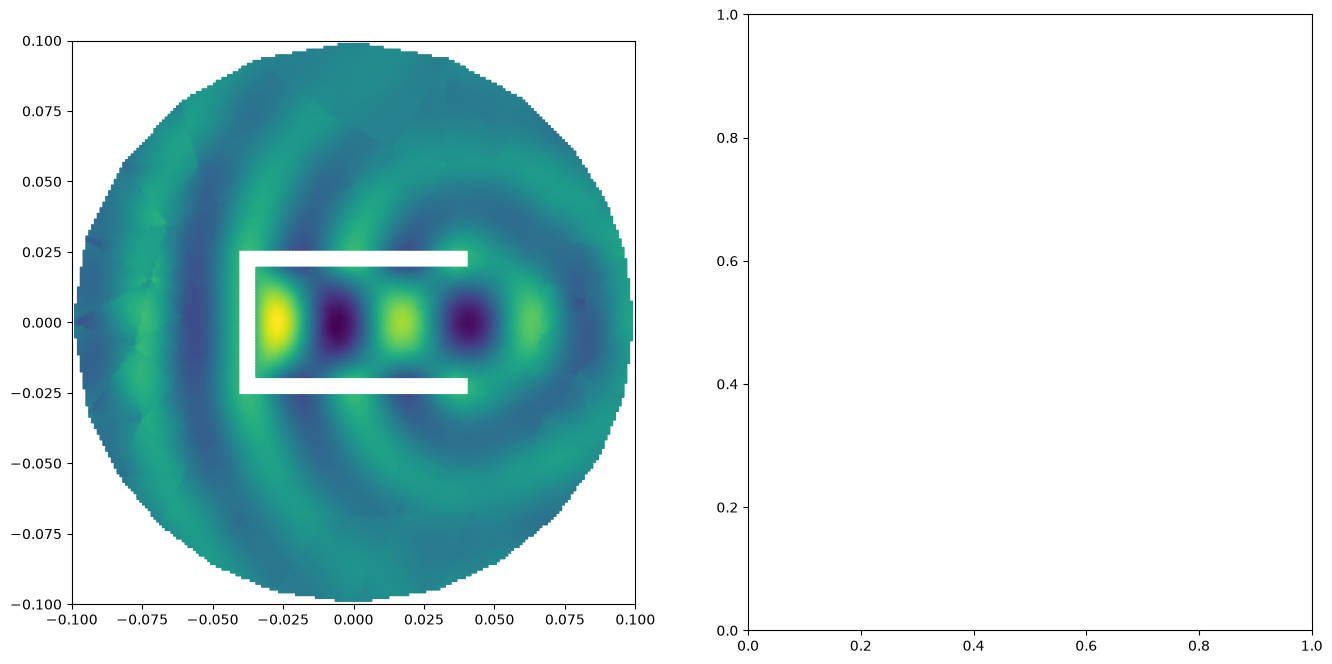

In [67]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

RHO = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y,X)
from scipy.special import jn, hankel1

Z_exact = -sum( 1j**n*jn(n, k*r)*hankel1(n, k*RHO)/hankel1(n, k*r)*np.exp(1j*n*(THETA-np.pi)) for n in range(-50,51))
Z_exact[RHO < r ] = np.nan
Z_exact[RHO > R ] = np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')

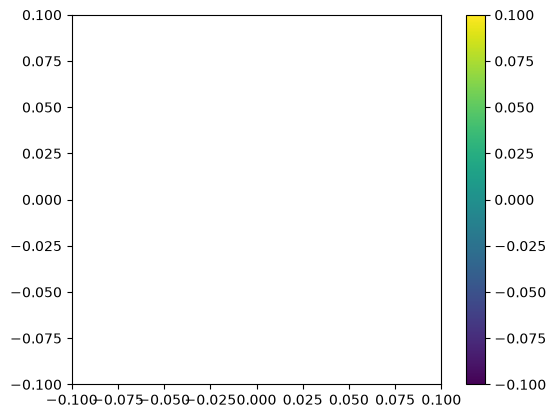

In [66]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()